In [122]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas                            
from shapely.geometry import Point

In [87]:
#SOCIOECONOMIC FACTORS DF
profile = pd.read_excel('wi_county_profile.xlsx', skiprows=2)
profile.rename(columns={profile.columns[0]: 'County'}, inplace=True)
profile.columns = profile.columns.str.strip()
profile.head()

,County,"Total Population - All Ages, All Races",60+,65+,75+,85+,% 60+,% 65+,% 75+,% 85+,...,Rental costs less than 30% of income,Percent with rental costs <30% of income,Rental costs 30% of income or more,Percent with rental costs >=30% of income or more,Number of units that are owner-occupied,Percent of units that are owner-occupied,Monthly owner costs less than 30% of income,Percent with monthly owner costs <30% of income,Monthly owner costs 30% of income or more,Percent with owner costs >=30% of income
0,Wisconsin,5914872,1514099,1096043,434379,124459,0.255982,0.185303,0.073438,0.021042,...,56619,0.358251,87122,0.551255,546591,0.775709,413533,0.756568,128749,0.235549
1,Adams,21123,9045,6803,2595,668,0.428206,0.322066,0.122852,0.031624,...,104,0.312312,126,0.378378,3952,0.922287,2866,0.725202,1052,0.266194
2,Ashland,16080,4731,3452,1316,459,0.294216,0.214677,0.081841,0.028545,...,166,0.340862,243,0.498973,1805,0.787522,1361,0.754017,439,0.243213
3,Barron,46797,14886,11028,4690,1241,0.318097,0.235656,0.100220,0.026519,...,558,0.382979,633,0.434454,5608,0.793772,4281,0.763374,1310,0.233595
4,Bayfield,16575,6838,5185,1901,497,0.412549,0.312821,0.114691,0.029985,...,152,0.406417,164,0.438503,2914,0.886253,2264,0.776939,645,0.221345


In [90]:
#keeping the important columns
needed_columns = [
    'County',
    'Total Population - All Ages, All Races',
    '% 65+',
    '% 75+',
    '% 85+',
    'Persons age 65+ (for poverty)',
    'Persons 65+ in poverty',
    '% of persons 65+ in poverty',
    'Total, Age 65+*',
    '% of 65+ Pop below poverty',
    '% of 65+ Pop: 150% of poverty or less',
    '% of 65+ Pop: 185% of poverty or less',
    '% of 65+ Pop: 200% of poverty or less',
    '% of 65+ Pop: 300% of poverty or less'
]
profile_final = profile[needed_columns].copy()
profile_final.set_index('County', inplace=True)
profile_final.head()

,"Total Population - All Ages, All Races",% 65+,% 75+,% 85+,Persons age 65+ (for poverty),Persons 65+ in poverty,% of persons 65+ in poverty,"Total, Age 65+*",% of 65+ Pop below poverty,% of 65+ Pop: 150% of poverty or less,% of 65+ Pop: 185% of poverty or less,% of 65+ Pop: 200% of poverty or less,% of 65+ Pop: 300% of poverty or less
County,,,,,,,,,,,,,
Wisconsin,5914872,0.185303,0.073438,0.021042,1069391,97230,0.090921,1069391,0.090921,0.159079,0.219553,0.254331,0.431926
Adams,21123,0.322066,0.122852,0.031624,6760,845,0.125000,6760,0.125000,0.213314,0.277071,0.352071,0.553846
Ashland,16080,0.214677,0.081841,0.028545,3280,572,0.174390,3280,0.174390,0.264939,0.319512,0.365244,0.529268
Barron,46797,0.235656,0.100220,0.026519,10723,963,0.089807,10723,0.089807,0.201529,0.259815,0.304859,0.530076
Bayfield,16575,0.312821,0.114691,0.029985,5123,358,0.069881,5123,0.069881,0.150693,0.210424,0.248292,0.428655


In [104]:
#MORTALITY DF
mort = pd.read_csv('mortality.csv', skiprows=4)
mort['County'] = mort['County'].str.replace(' County', '', case=False).str.strip()
#remove the info after buffalo
buffalo_idx = mort[mort['County'] == 'Buffalo'].index[0]
mort = mort.iloc[:buffalo_idx + 1]
mort = mort[['County', 'Age-Adjusted Death Rate(†) - deaths per 100,000','Average Annual Count']]
mort = mort[mort['County'] != 'United States']
mort.set_index('County', inplace=True)
mort.rename(index={'St. Croix': 'Saint Croix'}, inplace=True)
mort.head()

,"Age-Adjusted Death Rate(†) - deaths per 100,000",Average Annual Count
County,,
Wisconsin,665.6,28416.0
Menominee,1244.7,27.0
Lincoln,777.7,199.0
Milwaukee,774.1,4513.0
Juneau,757.2,155.0


In [116]:
#JOINED DF
county_info = pd.merge(mort, profile_final, on='County', how='inner')
county_info.columns = [
    'death_rate',
    'annual_count',
    'total_pop',
    'pct_65',
    'pct_75',
    'pct_85',
    'persons_65_poverty_base',
    'persons_65_in_poverty',
    'pct_65_in_poverty',
    'total_65',
    'pct_65_below_poverty',
    'pct_65_below_150_poverty',
    'pct_65_below_185_poverty',
    'pct_65_below_200_poverty',
    'pct_65_below_300_poverty',
]
county_info.head()

,death_rate,annual_count,total_pop,pct_65,pct_75,pct_85,persons_65_poverty_base,persons_65_in_poverty,pct_65_in_poverty,total_65,pct_65_below_poverty,pct_65_below_150_poverty,pct_65_below_185_poverty,pct_65_below_200_poverty,pct_65_below_300_poverty
County,,,,,,,,,,,,,,,
Wisconsin,665.6,28416.0,5914872,0.185303,0.073438,0.021042,1069391,97230,0.090921,1069391,0.090921,0.159079,0.219553,0.254331,0.431926
Menominee,1244.7,27.0,4252,0.167686,0.054563,0.023518,713,72,0.100982,713,0.100982,0.176718,0.279102,0.298738,0.497896
Lincoln,777.7,199.0,28426,0.236438,0.093963,0.029199,6495,789,0.121478,6495,0.121478,0.223403,0.293457,0.333487,0.502540
Milwaukee,774.1,4513.0,926331,0.147443,0.057024,0.018042,133251,19361,0.145297,133251,0.145297,0.229034,0.292328,0.330669,0.495133
Juneau,757.2,155.0,26689,0.218142,0.085241,0.023530,5644,661,0.117116,5644,0.117116,0.200921,0.285967,0.324415,0.532778


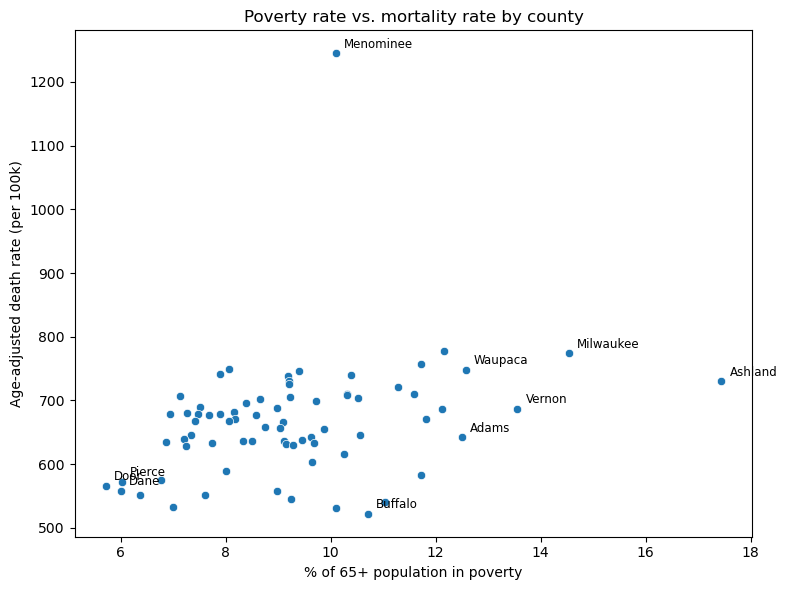

In [117]:
#PLOTTING POVERTY VS MORTALITY
county_info['pct_65_in_poverty_pct'] = county_info['pct_65_in_poverty'] * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=county_info, x='pct_65_in_poverty_pct', y='death_rate', ax=ax)

mean_d, std_d = county_info['death_rate'].mean(), county_info['death_rate'].std()
mean_p, std_p = county_info['pct_65_in_poverty_pct'].mean(), county_info['pct_65_in_poverty_pct'].std()

for county, row in county_info.iterrows():
    if abs(row['death_rate'] - mean_d) > 1.5 * std_d or abs(row['pct_65_in_poverty_pct'] - mean_p) > 1.5 * std_p:
        ax.annotate(county, (row['pct_65_in_poverty_pct'], row['death_rate']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8.5)

ax.set_xlabel('% of 65+ population in poverty')
ax.set_ylabel('Age-adjusted death rate (per 100k)')
ax.set_title('Poverty rate vs. mortality rate by county')
plt.tight_layout()
plt.show()

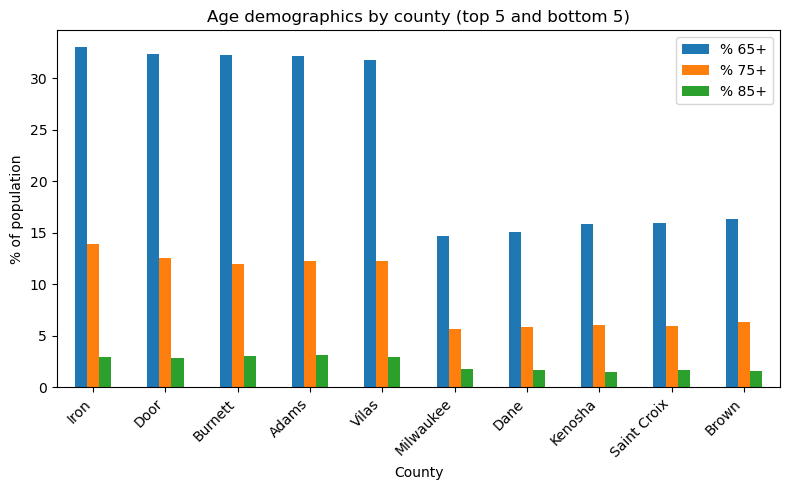

In [131]:
#PLOTTING AGE DEMOGRAPHICS
top5 = county_info.nlargest(5, 'pct_65')
bot5 = county_info.nsmallest(5, 'pct_65')
sample = pd.concat([top5, bot5])

sample[['pct_65', 'pct_75', 'pct_85']].mul(100).plot(kind='bar', figsize=(8, 5))

plt.xlabel('County')
plt.ylabel('% of population')
plt.title('Age demographics by county (top 5 and bottom 5)')
plt.legend(['% 65+', '% 75+', '% 85+'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

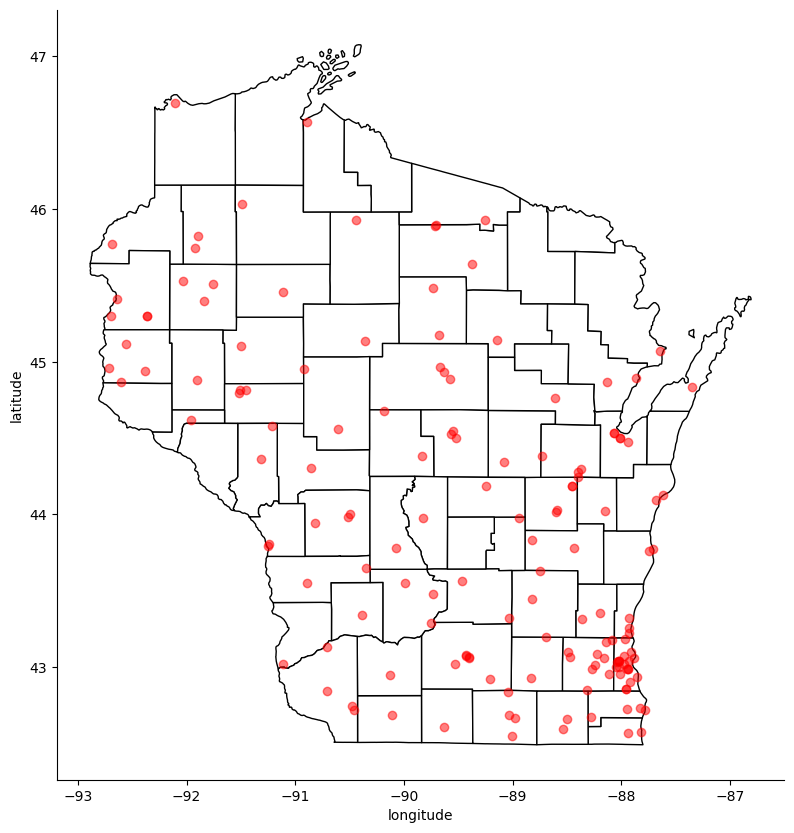

In [130]:
#PLOTTING HOSPTIALS IN WISCONSIN
us = geopandas.read_file('cb_2021_us_county_5m.zip')
wisco = us[us['STATE_NAME'] == 'Wisconsin']

hospitals = geopandas.read_file('Wisconsin_Hospitals.zip')

#fixing the Coordinate Reference System
hospitals = hospitals.to_crs(wisco.crs)

fig, gax = plt.subplots(figsize=(10,10))

wisco.plot(ax = gax, edgecolor='black',color='white')
hospitals.plot(ax = gax, color='red',alpha=0.5)

gax.set_xlabel('longitude')  
gax.set_ylabel('latitude')

gax.spines['top'].set_visible(False)
gax.spines['right'].set_visible(False)

plt.show()